In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import random
import time
import copy
from torch.utils.data import random_split
import torchvision
import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.utils.data
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset, TensorDataset
import torch.optim as optim
from torch.utils.data.sampler import SubsetRandomSampler, WeightedRandomSampler
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import cv2

In [ ]:
# GPU
cuda = torch.cuda.is_available()
print("GPU available:", cuda)

GPU available: True


In [ ]:

!pip -q install git+https://github.com/adalca/neurite.git@0776a575eadc3d10d6851a4679b7a305f3a31c65
!pip -q install git+https://github.com/voxelmorph/voxelmorph.git@375a1492bb8781cbbaf22f0ca2973e5121484f99


import os, sys

import numpy as np
import tensorflow as tf
assert tf.__version__.startswith('2.'), 'This tutorial assumes Tensorflow 2.0+'

import voxelmorph as vxm
import neurite as n

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


In [ ]:
import glob
import nibabel as nib

data_root_SCZ = '/content/dataset/MRI_Registration_DeepLearning/Dataset/SCZ_BrainGluSchi/SCZ'
SCZ_files = glob.glob(data_root_SCZ + '/*.nii.gz')

print(f"Total {len(SCZ_files)} SCZ MRI files found")
print("Shapes of the first 5 SCZ MRI files:")

for i, file_path in enumerate(SCZ_files[:5]):
    img = nib.load(file_path)
    data = img.get_fdata()
    print(f"File {i+1} shape: {data.shape}")

data_root_HC = '/content/dataset/MRI_Registration_DeepLearning/Dataset/SCZ_BrainGluSchi/HealthyControl'
HC_files = glob.glob(data_root_HC + '/*.nii.gz')

print(f"Total {len(HC_files)} HC MRI files found")
print("Shapes of the first 5 HC MRI files:")

for i, file_path in enumerate(HC_files[:5]):
    img = nib.load(file_path)
    data = img.get_fdata()
    print(f"File {i+1} shape: {data.shape}")

data_root_template = '/content/dataset/MRI_Registration_DeepLearning/Dataset/SCZ_BrainGluSchi/Template/MNI152_template'
template_files = glob.glob(data_root_template + '/*.nii.gz')

if len(template_files) == 0:
    print("\nNo MNI152 template found. Please check the path!")
else:
    print(f"\nTotal {len(template_files)} MNI152 template files found")

    # Load template and print shape
    img = nib.load(template_files[0])
    data = img.get_fdata()
    print(f"Template file shape: {data.shape}")



Mounted at /gdrive
Total 56 SCZ MRI files found
Shapes of the first 5 SCZ MRI files:
File 1 shape: (193, 229, 193)
File 2 shape: (193, 229, 193)
File 3 shape: (193, 229, 193)
File 4 shape: (193, 229, 193)
File 5 shape: (193, 229, 193)
Total 91 HC MRI files found
Shapes of the first 5 HC MRI files:
File 1 shape: (193, 229, 193)
File 2 shape: (193, 229, 193)
File 3 shape: (193, 229, 193)
File 4 shape: (193, 229, 193)
File 5 shape: (193, 229, 193)

 Total 1 MNI152 template files found
Template file shape: (193, 229, 193)


Random SCZ file: /gdrive/MyDrive/dataset/MRI_Registration_DeepLearning/Dataset/SCZ_BrainGluSchi/SCZ/MNI152_affine_WB_MNI152_affine_WH_iso1mm_BrainGluSchi_sub-A00019803_ses-20100101_acq-mprage_T1w_echo_raw_WB.nii.gz
Random HC file: /gdrive/MyDrive/dataset/MRI_Registration_DeepLearning/Dataset/SCZ_BrainGluSchi/HealthyControl/MNI152_affine_WB_MNI152_affine_WH_iso1mm_BrainGluSchi_sub-A00034389_ses-20120101_acq-mprage_T1w_echo_raw_WB.nii.gz
Template file: /gdrive/MyDrive/dataset/MRI_Registration_DeepLearning/Dataset/SCZ_BrainGluSchi/Template/MNI152_template/icbm_avg_152_t1_tal_nlin_symmetric_VI_WB_template.nii.gz


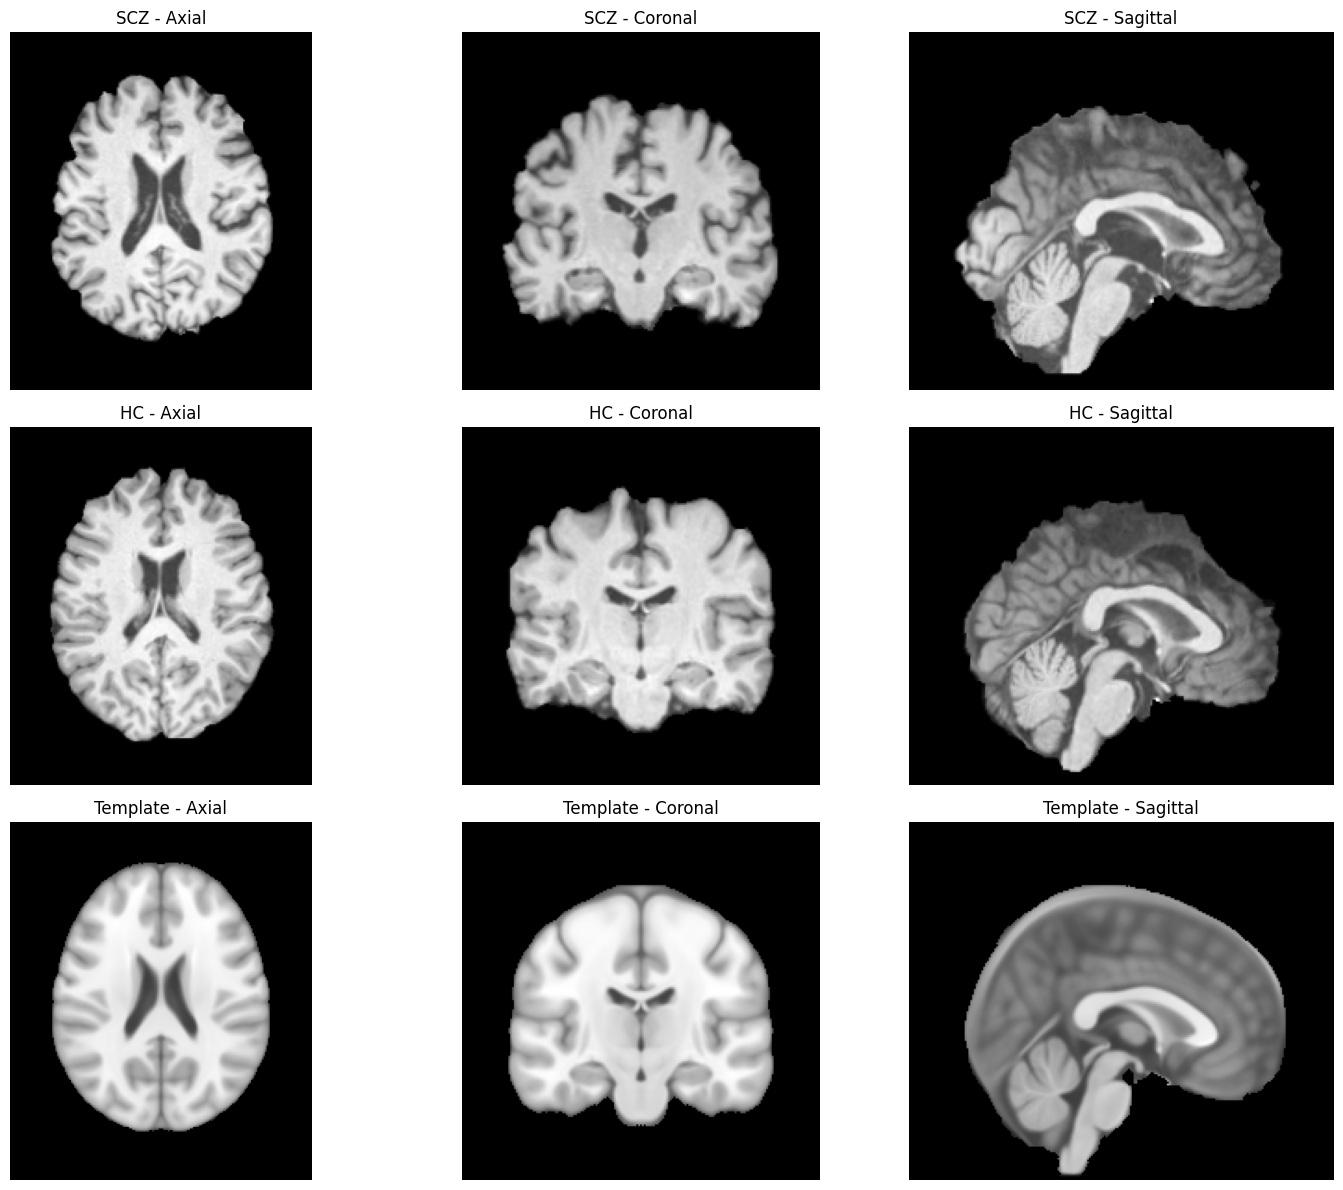

In [ ]:
import random
import matplotlib.pyplot as plt

def show_middle_slices_3view(SCZ_files, HC_files, template_file):

    # Randomly select one SCZ and one HC
    scz_sample = random.choice(SCZ_files)
    hc_sample = random.choice(HC_files)

    print(f"Random SCZ file: {scz_sample}")
    print(f"Random HC file: {hc_sample}")
    print(f"Template file: {template_file}")

    # Load SCZ
    scz_img = nib.load(scz_sample)
    scz_data = scz_img.get_fdata()
    scz_mid = [s//2 for s in scz_data.shape]

    # Load HC
    hc_img = nib.load(hc_sample)
    hc_data = hc_img.get_fdata()
    hc_mid = [s//2 for s in hc_data.shape]

    # Load Template
    template_img = nib.load(template_file)
    template_data = template_img.get_fdata()
    template_mid = [s//2 for s in template_data.shape]

    # Plot
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))

    # SCZ
    axes[0, 0].imshow(scz_data[:, :, scz_mid[2]].T, cmap="gray", origin="lower")
    axes[0, 0].set_title("SCZ - Axial")
    axes[0, 1].imshow(scz_data[:, scz_mid[1], :].T, cmap="gray", origin="lower")
    axes[0, 1].set_title("SCZ - Coronal")
    axes[0, 2].imshow(scz_data[scz_mid[0], :, :].T, cmap="gray", origin="lower")
    axes[0, 2].set_title("SCZ - Sagittal")

    # HC
    axes[1, 0].imshow(hc_data[:, :, hc_mid[2]].T, cmap="gray", origin="lower")
    axes[1, 0].set_title("HC - Axial")
    axes[1, 1].imshow(hc_data[:, hc_mid[1], :].T, cmap="gray", origin="lower")
    axes[1, 1].set_title("HC - Coronal")
    axes[1, 2].imshow(hc_data[hc_mid[0], :, :].T, cmap="gray", origin="lower")
    axes[1, 2].set_title("HC - Sagittal")

    # Template
    axes[2, 0].imshow(template_data[:, :, template_mid[2]].T, cmap="gray", origin="lower")
    axes[2, 0].set_title("Template - Axial")
    axes[2, 1].imshow(template_data[:, template_mid[1], :].T, cmap="gray", origin="lower")
    axes[2, 1].set_title("Template - Coronal")
    axes[2, 2].imshow(template_data[template_mid[0], :, :].T, cmap="gray", origin="lower")
    axes[2, 2].set_title("Template - Sagittal")

    # Clean axes
    for ax_row in axes:
        for ax in ax_row:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

# Run it
show_middle_slices_3view(SCZ_files, HC_files, template_files[0])


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import nibabel as nib
import numpy as np
import torch.nn.functional as F

class MRIDataset(Dataset):
    def __init__(self, file_list, resize_shape=(160, 192, 224)):

        self.file_list = file_list
        self.resize_shape = resize_shape

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = self.file_list[idx]
        img = nib.load(file_path)
        data = img.get_fdata()

        data = (data - np.min(data)) / (np.max(data) - np.min(data) + 1e-5)

        data = torch.from_numpy(data).float().unsqueeze(0)

        data = F.interpolate(data.unsqueeze(0), size=self.resize_shape, mode='trilinear', align_corners=False)
        data = data.squeeze(0)

        return data

resize_shape = (160, 192, 224)

scz_dataset = MRIDataset(SCZ_files, resize_shape=resize_shape)
scz_loader = DataLoader(scz_dataset, batch_size=4, shuffle=True, num_workers=2)

hc_dataset = MRIDataset(HC_files, resize_shape=resize_shape)
hc_loader = DataLoader(hc_dataset, batch_size=4, shuffle=True, num_workers=2)

template_dataset = MRIDataset(template_files, resize_shape=resize_shape)
template_tensor = template_dataset[0]


In [ ]:
import voxelmorph as vxm
import neurite as ne

input_shape = (160, 192, 224)
nb_features = [
    [16, 32, 32, 32],
    [32, 32, 32, 32, 32, 16, 16]
]

vxm_model = vxm.networks.VxmDense(
    inshape=input_shape,
    nb_unet_features=nb_features,
    int_steps=0
)

vxm_model.summary()

Model: "vxm_dense"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ vxm_dense_source_i… │ (None, 160, 192,  │          0 │ -                 │
│ (InputLayer)        │ 224, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vxm_dense_target_i… │ (None, 160, 192,  │          0 │ -                 │
│ (InputLayer)        │ 224, 1)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vxm_dense_unet_inp… │ (None, 160, 192,  │          0 │ vxm_dense_source… │
│ (Concatenate)       │ 224, 2)           │            │ vxm_dense_target… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vxm_dense_unet_enc… │ (None, 160, 192,  │        880 │ vxm_dense_unet_i… │
│ (Conv3D)            │ 224, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vxm_dense_unet_enc… │ (None, 160, 192,  │          0 │ vxm_dense_unet_e… │
│ (LeakyReLU)         │ 224, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vxm_dense_unet_enc… │ (None, 80, 96,    │          0 │ vxm_dense_unet_e… │
│ (MaxPooling3D)      │ 112, 16)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vxm_dense_unet_enc… │ (None, 80, 96,    │     13,856 │ vxm_dense_unet_e… │
│ (Conv3D)            │ 112, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vxm_dense_unet_enc… │ (None, 80, 96,    │          0 │ vxm_dense_unet_e… │
│ (LeakyReLU)         │ 112, 32)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vxm_dense_unet_enc… │ (None, 40, 48,    │          0 │ vxm_dense_unet_e… │
│ (MaxPooling3D)      │ 56, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vxm_dense_unet_enc… │ (None, 40, 48,    │     27,680 │ vxm_dense_unet_e… │
│ (Conv3D)            │ 56, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vxm_dense_unet_enc… │ (None, 40, 48,    │          0 │ vxm_dense_unet_e… │
│ (LeakyReLU)         │ 56, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vxm_dense_unet_enc… │ (None, 20, 24,    │          0 │ vxm_dense_unet_e… │
│ (MaxPooling3D)      │ 28, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vxm_dense_unet_enc… │ (None, 20, 24,    │     27,680 │ vxm_dense_unet_e… │
│ (Conv3D)            │ 28, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vxm_dense_unet_enc… │ (None, 20, 24,    │          0 │ vxm_dense_unet_e… │
│ (LeakyReLU)         │ 28, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vxm_dense_unet_enc… │ (None, 10, 12,    │          0 │ vxm_dense_unet_e… │
│ (MaxPooling3D)      │ 14, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vxm_dense_unet_dec… │ (None, 10, 12,    │     27,680 │ vxm_dense_unet_e… │
│ (Conv3D)            │ 14, 32)           │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vxm_dense_unet_dec… │ (None, 10, 12,    │          0 │ vxm_dense_unet_d

 Total params: 327,331 (1.25 MB)

 Trainable params: 327,331 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import train_test_split

# Combine SCZ and HC into one dataset
all_files = SCZ_files + HC_files

# Split: 80% train, 20% temp
train_files, temp_files = train_test_split(all_files, test_size=0.2, random_state=42)

# Split temp into 10% val and 10% test
val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=42)

print(f"Train set: {len(train_files)} files")
print(f"Validation set: {len(val_files)} files")
print(f"Test set: {len(test_files)} files")

Train set: 117 files
Validation set: 15 files
Test set: 15 files


In [ ]:

train_dataset = MRIDataset(train_files, resize_shape=resize_shape)
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=2)

val_dataset = MRIDataset(val_files, resize_shape=resize_shape)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=2)

test_dataset = MRIDataset(test_files, resize_shape=resize_shape)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=2)


In [ ]:
ncc_loss = vxm.losses.NCC().loss
grad_loss = vxm.losses.Grad(penalty='l2').loss

alpha = 0.2

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam

# Optimizer
optimizer = Adam(learning_rate=1e-4)

In [ ]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

In [ ]:
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import mixed_precision
from tensorflow.keras.optimizers.schedules import LearningRateSchedule

mixed_precision.set_global_policy('mixed_float16')

class WarmupDecay(LearningRateSchedule):
    def __init__(self, base_lr, warmup_epochs):
        super(WarmupDecay, self).__init__()
        self.base_lr = tf.cast(base_lr, tf.float32)
        self.warmup_epochs = warmup_epochs

    def __call__(self, step):
        epoch = tf.cast(step // len(train_loader), tf.float32)

        # Warm-up logic
        warmup_factor = tf.minimum(1.0, (epoch + 1) / self.warmup_epochs)
        lr = self.base_lr * warmup_factor

        return lr

base_lr = 1e-4
warmup_epochs = 10

lr_schedule = WarmupDecay(base_lr, warmup_epochs)
optimizer = Adam(learning_rate=lr_schedule)

os.makedirs('./model_ckpt', exist_ok=True)

if os.path.exists('./model_ckpt/train_losses.npy'):
    train_losses = list(np.load('./model_ckpt/train_losses.npy'))
    print(f" Loaded existing train_losses, length={len(train_losses)}")
else:
    train_losses = []

if os.path.exists('./model_ckpt/val_losses.npy'):
    val_losses = list(np.load('./model_ckpt/val_losses.npy'))
    print(f" Loaded existing val_losses, length={len(val_losses)}")
else:
    val_losses = []

if os.path.exists('./model_ckpt/best_model.h5'):
    print(" Existing best model found, continuing training...")
    best_val_loss = min(val_losses) if val_losses else float('inf')
else:
    best_val_loss = float('inf')

# EarlyStopping
patience = 10
no_improve_counter = 0
max_epoch = 100

for epoch in range(len(train_losses) + 1, max_epoch + 1):
    print(f"\nEpoch {epoch}/{max_epoch}")

    train_loss_sum = 0
    for batch in train_loader:
        moving = batch.permute(0, 2, 3, 4, 1)
        fixed = torch.from_numpy(template_tensor.numpy()).repeat(moving.shape[0], 1, 1, 1, 1).permute(0, 2, 3, 4, 1)

        moving_tf = tf.convert_to_tensor(moving.numpy())
        fixed_tf = tf.convert_to_tensor(fixed.numpy())

        with tf.GradientTape() as tape:
            y_pred, flow = vxm_model([moving_tf, fixed_tf], training=True)
            sim = ncc_loss(fixed_tf, y_pred)
            smooth = grad_loss(None, flow)
            loss = sim + alpha * smooth

        grads = tape.gradient(loss, vxm_model.trainable_variables)
        optimizer.apply_gradients(zip(grads, vxm_model.trainable_variables))

        train_loss_sum += float(np.mean(loss.numpy()))

    train_loss_avg = train_loss_sum / len(train_loader)
    train_losses.append(train_loss_avg)
    print(f"Train Loss: {train_loss_avg:.5f}")

    val_loss_sum = 0
    for batch in val_loader:
        moving = batch.permute(0, 2, 3, 4, 1)
        fixed = torch.from_numpy(template_tensor.numpy()).repeat(moving.shape[0], 1, 1, 1, 1).permute(0, 2, 3, 4, 1)

        moving_tf = tf.convert_to_tensor(moving.numpy())
        fixed_tf = tf.convert_to_tensor(fixed.numpy())

        y_pred, flow = vxm_model([moving_tf, fixed_tf], training=False)
        sim = ncc_loss(fixed_tf, y_pred)
        smooth = grad_loss(None, flow)
        loss = sim + alpha * smooth

        val_loss_sum += float(np.mean(loss.numpy()))

    val_loss_avg = val_loss_sum / len(val_loader)
    val_losses.append(val_loss_avg)
    print(f"Val Loss: {val_loss_avg:.5f}")

    if val_loss_avg < best_val_loss:
        best_val_loss = val_loss_avg
        no_improve_counter = 0
        vxm_model.save('./model_ckpt/best_model.h5')
        print(" Saved new best model!")
    else:
        no_improve_counter += 1
        print(f" No improvement. patience counter: {no_improve_counter}/{patience}")

    np.save('./model_ckpt/train_losses.npy', np.array(train_losses))
    np.save('./model_ckpt/val_losses.npy', np.array(val_losses))

    if no_improve_counter >= patience:
        print(f" Early stopping triggered at epoch {epoch}!")
        break

print(" Training completed and checkpoint secured!")




Epoch 1/100
Train Loss: -0.80621


Val Loss: -0.81201
 Saved new best model!

Epoch 2/100
Train Loss: -0.81390


Val Loss: -0.82118
 Saved new best model!

Epoch 3/100
Train Loss: -0.82877


Val Loss: -0.83881
 Saved new best model!

Epoch 4/100
Train Loss: -0.84166


Val Loss: -0.84648
 Saved new best model!

Epoch 5/100
Train Loss: -0.85061


...

Val Loss: -0.94595
 Saved new best model!

Epoch 94/100
Train Loss: -0.94487
Val Loss: -0.94557
 No improvement. patience counter: 1/10

Epoch 95/100
Train Loss: -0.94488
Val Loss: -0.94595
 No improvement. patience counter: 2/10

Epoch 96/100
Train Loss: -0.94509
Val Loss: -0.94593
 No improvement. patience counter: 3/10

Epoch 97/100
Train Loss: -0.94368


Val Loss: -0.94628
 Saved new best model!

Epoch 98/100
Train Loss: -0.94581


Val Loss: -0.94680
 Saved new best model!

Epoch 99/100
Train Loss: -0.94579


Val Loss: -0.94687
 Saved new best model!

Epoch 100/100
Train Loss: -0.94608


Val Loss: -0.94705
 Saved new best model!
 Training completed and checkpoint secured!
